In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

data = pd.read_csv("../data_files/beverage_factory_quality_data.csv")

data.head()

,Batch_ID,Inspected_Bottles,Quality_Bottles,Defective_Bottles
0,1,10,10,0
1,2,10,9,1
2,3,10,10,0
3,4,10,9,1
4,5,10,8,2


In [12]:
defective_counts = data['Defective_Bottles']


In [4]:
n = data['Inspected_Bottles'].iloc[2]
n

np.int64(10)

In [13]:
p_value = defective_counts.value_counts().sort_index()/n
p_value

Defective_Bottles
0    4.0
1    3.3
2    2.2
3    0.5
Name: count, dtype: float64

In [14]:
freq = defective_counts.value_counts().sort_index()
freq

Defective_Bottles
0    40
1    33
2    22
3     5
Name: count, dtype: int64

In [17]:
len(defective_counts)

100

In [18]:
pmf = freq/len(defective_counts)
pmf

Defective_Bottles
0    0.40
1    0.33
2    0.22
3    0.05
Name: count, dtype: float64

In [19]:
pmf.sum()

np.float64(1.0)

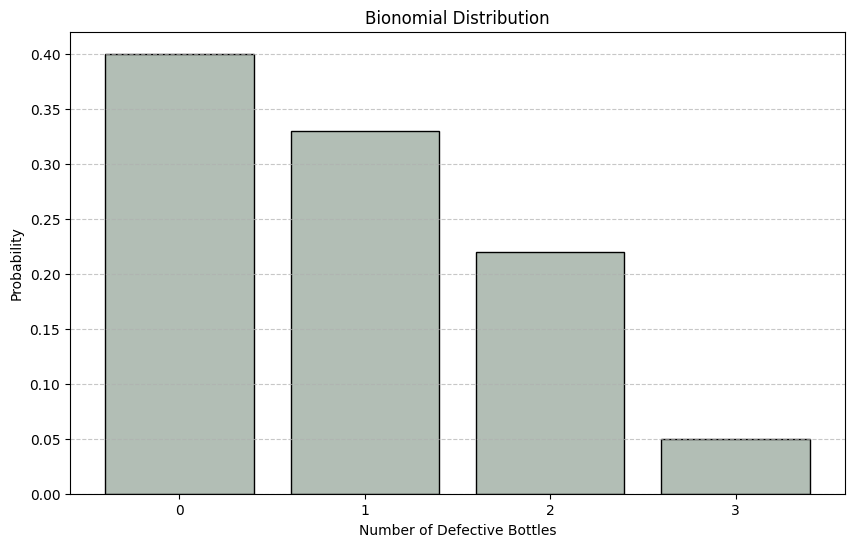

In [32]:
plt.figure(figsize=(10, 6))
plt.bar(pmf.index, pmf.values, color='#a1caf1', edgecolor='black', facecolor='#b2beb5')
plt.title("Bionomial Distribution")
plt.xlabel("Number of Defective Bottles")
plt.ylabel("Probability")
plt.xticks(pmf.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [34]:
mean = defective_counts.mean()
mean

np.float64(0.92)

In [35]:
variance = defective_counts.var()
variance

np.float64(0.8218181818181817)

In [36]:
std = np.sqrt(variance)
std

np.float64(0.9065418808958479)

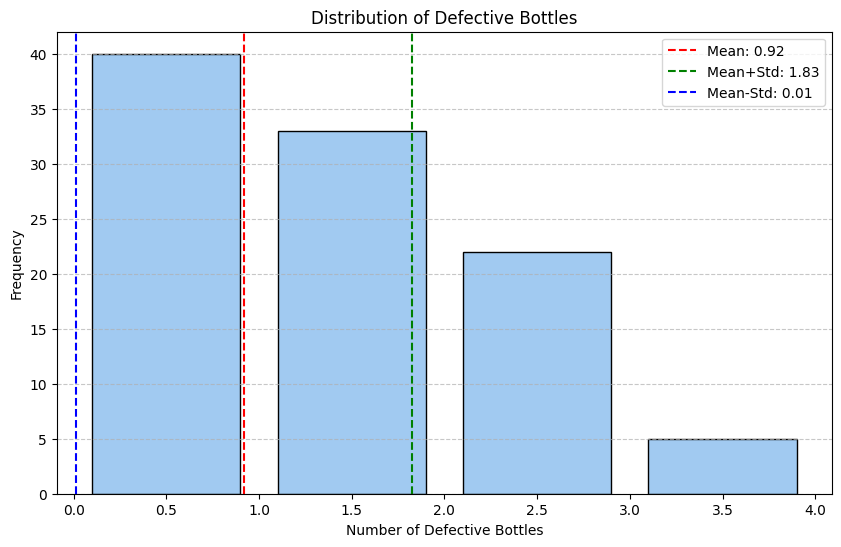

In [46]:
plt.figure(figsize=(10, 6))
plt.hist(defective_counts, bins=range(defective_counts.min(), defective_counts.max()+2), rwidth=0.8, color='#a1caf1', edgecolor='black')
plt.axvline(mean, color='red', linestyle='dashed', linewidth=1.5, label = f"Mean: {mean:.2f}")
plt.axvline(mean+std, color='green', linestyle='dashed', linewidth=1.5, label = f"Mean+Std: {mean+std:.2f}")
plt.axvline(mean-std, color='blue', linestyle='dashed', linewidth=1.5, label = f"Mean-Std: {mean-std:.2f}")
plt.title("Distribution of Defective Bottles")
plt.xlabel("Number of Defective Bottles")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()